# Feature engineering 

Per 2 s window: time-domain stats, FFT features via FourierTransformation, magnitude signals, and cross-axis correlations. Features are built for the unified window table so later notebooks can define each experiment from the session-aware split columns.

In [13]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
ML4QS_CODE = ROOT.parent / 'ML4QS' / 'Python3Code'
sys.path.insert(0, str(ML4QS_CODE))
from Chapter4.FrequencyAbstraction import FourierTransformation

WIN = ROOT / 'windowed_data'
FEAT = ROOT / 'features'
FIG = ROOT / 'figures'
FEAT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

HZ = 100
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
BANDS = [(0, 1), (1, 3), (3, 5), (5, np.inf)]
BAND_NAMES = ['0_1hz', '1_3hz', '3_5hz', 'gt_5hz']
CORR_PAIRS = [
    ('acc_x', 'acc_y'), ('acc_y', 'acc_z'), ('acc_x', 'acc_z'),
    ('gyro_x', 'gyro_y'), ('gyro_y', 'gyro_z'),
]
META_COLS = {
    'participant', 'context', 'session', 'window_idx', 'label_person', 'label_context',
    'split_owner_person', 'split_context', 'use_owner_person', 'use_context',
    'participant_id', 'label_owner', 'label_context_bin',
}


def safe_corr(a, b):
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    c = np.corrcoef(a, b)[0, 1]
    return 0.0 if np.isnan(c) else float(c)


def time_features(x, prefix):
    x = np.asarray(x, dtype=float)
    return {
        f'{prefix}_mean': np.mean(x), f'{prefix}_std': np.std(x),
        f'{prefix}_median': np.median(x), f'{prefix}_min': np.min(x),
        f'{prefix}_max': np.max(x), f'{prefix}_rms': np.sqrt(np.mean(x ** 2)),
    }


def freq_features_ml4qs(x, prefix, fs=HZ):
    x = np.asarray(x, dtype=float) - np.mean(x)
    n = len(x)
    ft = FourierTransformation()
    ft.freqs = (fs * np.fft.rfftfreq(n)).round(3)
    ft.temp_list = []
    ft.find_fft_transformation(x)
    row = ft.temp_list[0]
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    power = np.abs(np.fft.rfft(x)) ** 2
    out = {f'{prefix}_dom_freq': float(row[2]), f'{prefix}_spec_entropy': float(row[0])}
    for (lo, hi), name in zip(BANDS, BAND_NAMES):
        mask = (freqs >= lo) & (freqs < hi)
        out[f'{prefix}_band_{name}'] = float(power[mask].sum())
    return out


def extract_window_features(window):
    signals = {c: window[:, i] for i, c in enumerate(SENSOR_COLS)}
    signals['acc_magnitude'] = np.sqrt((window[:, :3] ** 2).sum(axis=1))
    signals['gyro_magnitude'] = np.sqrt((window[:, 3:] ** 2).sum(axis=1))
    feats = {}
    for name, sig in signals.items():
        feats.update(time_features(sig, name))
        feats.update(freq_features_ml4qs(sig, name))
    for a, b in CORR_PAIRS:
        feats[f'corr_{a}_{b}'] = safe_corr(signals[a], signals[b])
    return feats


def build_feature_matrix(X, meta):
    rows = []
    for i in range(len(meta)):
        row = meta.iloc[i].to_dict()
        row.update(extract_window_features(X[i]))
        rows.append(row)
    df = pd.DataFrame(rows)
    df['participant_id'] = df['participant']
    df['label_owner'] = (df['participant'] == 'Pedro').astype(int)
    df['label_context_bin'] = (df['context'] == 'crowded').astype(int)
    return df


def get_feature_cols(df):
    return [c for c in df.columns if c not in META_COLS]

In [14]:
meta_all = pd.read_csv(WIN / 'meta_all.csv')
X_all = np.load(WIN / 'X_all.npy')

features_df = build_feature_matrix(X_all, meta_all)
feat_cols = get_feature_cols(features_df)

features_df[feat_cols] = features_df[feat_cols].replace([np.inf, -np.inf], np.nan)
train_mask = (features_df['split_owner_person'] == 'train') | (features_df['split_context'] == 'train')
med = features_df.loc[train_mask, feat_cols].median()
features_df[feat_cols] = features_df[feat_cols].fillna(med)

print('Feature matrix all:', features_df[feat_cols].shape)
print('NaNs:', int(features_df[feat_cols].isna().sum().sum()))
print('\nOwner/person split counts:')
print(features_df[features_df['split_owner_person'] != 'ignore'].groupby(['split_owner_person', 'participant']).size())
print('\nContext split counts:')
print(features_df[features_df['split_context'] != 'ignore'].groupby(['split_context', 'context']).size())

features_df.to_csv(FEAT / 'feature_matrix_all.csv', index=False)

Feature matrix all: (4805, 101)
NaNs: 0

Owner/person split counts:
split_owner_person  participant
test                Asena          179
                    Darius         179
                    Jun            179
                    Oana           179
                    Pedro          179
train               Asena          358
                    Darius         358
                    Jun            358
                    Oana           358
                    Pedro          358
dtype: int64

Context split counts:
split_context  context
test           crowded    891
               normal     895
train          crowded    887
               normal     895
dtype: int64


## PCA analysis

Fit PCA on the owner/person training subset only, inspect explained variance, save PCA coordinates for the full feature table, and inspect which original features drive the first components.

Components for 90% variance: 27
Components for 95% variance: 38
First 10 explained variance ratios: [0.2779 0.2284 0.0541 0.0423 0.0383 0.03   0.0268 0.0252 0.0191 0.0168]


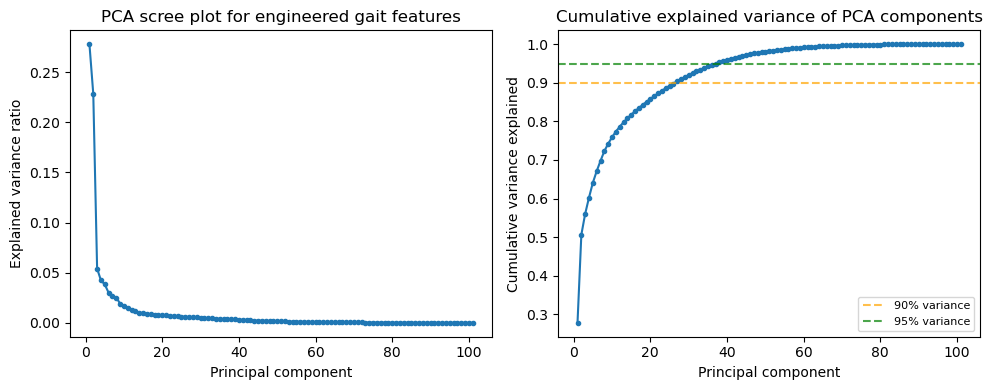


Top loadings for PC1:
                          pc_1_loading_abs  pc_2_loading_abs
acc_magnitude_rms                 0.179925          0.004894
acc_magnitude_std                 0.177699          0.009043
acc_y_std                         0.174579          0.025388
gyro_magnitude_mean               0.170477          0.073238
gyro_magnitude_median             0.170341          0.042268
gyro_magnitude_rms                0.168726          0.081205
gyro_x_rms                        0.168231          0.065564
gyro_x_std                        0.167858          0.064409
acc_magnitude_max                 0.164286          0.031053
acc_magnitude_band_1_3hz          0.164060          0.042449


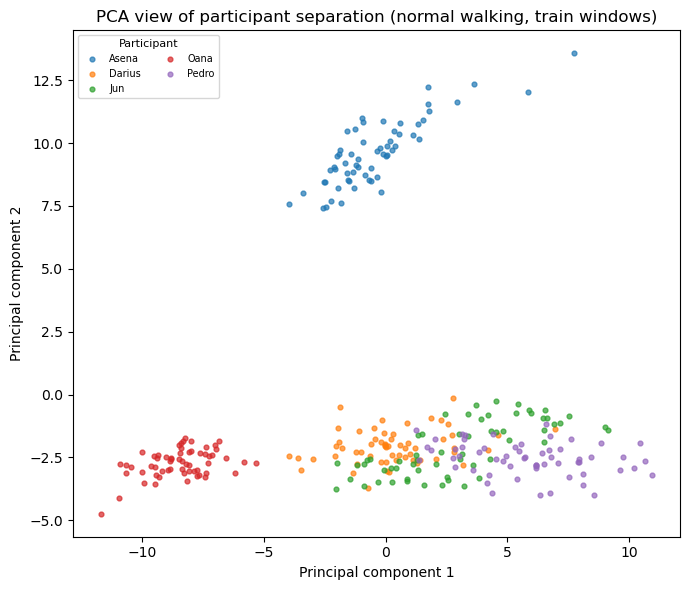


Saved PCA outputs:
 - /Users/pedropinto/school/Msc Artificial Intelligence/MLQS/ML4QS/Experiment/features/feature_matrix_all_pca.csv
 - /Users/pedropinto/school/Msc Artificial Intelligence/MLQS/ML4QS/Experiment/features/pca_loadings.csv


In [15]:
meta_cols = [c for c in features_df.columns if c in META_COLS]
pca_train = features_df[features_df['split_owner_person'] == 'train'].reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(pca_train[feat_cols])
X_all_scaled = scaler.transform(features_df[feat_cols])

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_all_pca = pca.transform(X_all_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()
n90 = int(np.argmax(cum_explained >= 0.90) + 1)
n95 = int(np.argmax(cum_explained >= 0.95) + 1)

print('Components for 90% variance:', n90)
print('Components for 95% variance:', n95)
print('First 10 explained variance ratios:', np.round(explained[:10], 4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(1, len(explained) + 1), explained, marker='o', ms=3)
axes[0].set_title('PCA scree plot for engineered gait features')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[1].plot(range(1, len(cum_explained) + 1), cum_explained, marker='o', ms=3)
axes[1].axhline(0.90, color='orange', ls='--', alpha=0.7, label='90% variance')
axes[1].axhline(0.95, color='green', ls='--', alpha=0.7, label='95% variance')
axes[1].set_title('Cumulative explained variance of PCA components')
axes[1].set_xlabel('Principal component')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / 'fig16_pca_explained_variance.png', dpi=150)
plt.show()

pca_cols = [f'pc_{i+1}' for i in range(n95)]
features_pca_df = pd.concat([
    features_df[meta_cols].reset_index(drop=True),
    pd.DataFrame(X_all_pca[:, :n95], columns=pca_cols)
], axis=1)
features_pca_df.to_csv(FEAT / 'feature_matrix_all_pca.csv', index=False)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feat_cols,
    columns=[f'pc_{i+1}' for i in range(len(feat_cols))]
)
loadings.to_csv(FEAT / 'pca_loadings.csv')

loading_summary = pd.DataFrame({
    'pc_1_loading_abs': loadings['pc_1'].abs(),
    'pc_2_loading_abs': loadings['pc_2'].abs(),
}).sort_values('pc_1_loading_abs', ascending=False)
print('\nTop loadings for PC1:')
print(loading_summary.head(10))

plot_df = features_pca_df[features_pca_df['split_owner_person'] == 'train'].copy()
fig, ax = plt.subplots(figsize=(7, 6))
for participant, sub in plot_df.groupby('participant'):
    sample = sub.sample(min(60, len(sub)), random_state=42)
    ax.scatter(sample['pc_1'], sample['pc_2'], s=12, alpha=0.7, label=participant)
ax.set_title('PCA view of participant separation (normal walking, train windows)')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
ax.legend(title='Participant', fontsize=7, title_fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG / 'fig17_pca_pc1_pc2_person_id.png', dpi=150)
plt.show()

print('\nSaved PCA outputs:')
print(' -', FEAT / 'feature_matrix_all_pca.csv')
print(' -', FEAT / 'pca_loadings.csv')

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
person_train = features_df[features_df['split_owner_person'] == 'train'].copy()
rf.fit(person_train[feat_cols], person_train['label_person'])
importance_series = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)

SIGNAL_NAME_MAP = {
    'acc_x': 'Lateral acceleration',
    'acc_y': 'Vertical acceleration',
    'acc_z': 'Forward acceleration',
    'gyro_x': 'Roll rate',
    'gyro_y': 'Pitch rate',
    'gyro_z': 'Yaw rate',
    'acc_magnitude': 'Acceleration magnitude',
    'gyro_magnitude': 'Gyroscope magnitude',
}
STAT_NAME_MAP = {
    'mean': 'mean',
    'std': 'standard deviation',
    'median': 'median',
    'min': 'minimum',
    'max': 'maximum',
    'rms': 'RMS',
    'dom_freq': 'dominant frequency',
    'spec_entropy': 'spectral entropy',
    'band_0_1hz': 'band power 0-1 Hz',
    'band_1_3hz': 'band power 1-3 Hz',
    'band_3_5hz': 'band power 3-5 Hz',
    'band_gt_5hz': 'band power >5 Hz',
}


def pretty_feature_label(feature_name):
    if feature_name.startswith('corr_'):
        _, a, b, c, d = feature_name.split('_')
        left = SIGNAL_NAME_MAP[f'{a}_{b}']
        right = SIGNAL_NAME_MAP[f'{c}_{d}']
        return f'Correlation: {left} vs {right}'

    for signal in sorted(SIGNAL_NAME_MAP, key=len, reverse=True):
        prefix = f'{signal}_'
        if feature_name.startswith(prefix):
            stat = feature_name[len(prefix):]
            stat_label = STAT_NAME_MAP.get(stat, stat.replace('_', ' '))
            return f"{SIGNAL_NAME_MAP[signal]} ({stat_label})"
    return feature_name.replace('_', ' ')


pc1_top = loadings['pc_1'].abs().sort_values(ascending=False).head(8)
pc2_top = loadings['pc_2'].abs().sort_values(ascending=False).head(8)
selected_features = list(dict.fromkeys(pc1_top.index.tolist() + pc2_top.index.tolist()))
loading_table = pd.DataFrame({
    'feature': selected_features,
    'feature_label': [pretty_feature_label(f) for f in selected_features],
    'pc_1_loading': loadings.loc[selected_features, 'pc_1'].values,
    'pc_1_loading_abs': loadings.loc[selected_features, 'pc_1'].abs().values,
    'pc_2_loading': loadings.loc[selected_features, 'pc_2'].values,
    'pc_2_loading_abs': loadings.loc[selected_features, 'pc_2'].abs().values,
}).sort_values(['pc_1_loading_abs', 'pc_2_loading_abs'], ascending=False)
loading_table.to_csv(FEAT / 'pca_top_feature_drivers.csv', index=False)

print('\nTop original features contributing to PC1 and PC2:')
print(loading_table[['feature_label', 'pc_1_loading', 'pc_2_loading']].to_string(index=False))
print('\nSaved:', FEAT / 'pca_top_feature_drivers.csv')


def infer_signal_group(feature_name):
    if feature_name.startswith('corr_'):
        return 'Cross-axis correlation'
    for signal in ['acc_magnitude', 'gyro_magnitude', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']:
        if feature_name.startswith(f'{signal}_'):
            if signal.startswith('acc_') and signal != 'acc_magnitude':
                return 'Acceleration axes'
            if signal.startswith('gyro_') and signal != 'gyro_magnitude':
                return 'Gyroscope axes'
            if signal == 'acc_magnitude':
                return 'Acceleration magnitude'
            if signal == 'gyro_magnitude':
                return 'Gyroscope magnitude'
    return 'Other'


def infer_stat_group(feature_name):
    if feature_name.startswith('corr_'):
        return 'Correlation'
    suffix = feature_name.split('_', 2)[-1]
    if suffix in {'mean', 'std', 'median', 'min', 'max', 'rms'}:
        return 'Time-domain statistics'
    if suffix in {'dom_freq', 'spec_entropy'} or suffix.startswith('band_'):
        return 'Frequency-domain statistics'
    return 'Other'


importance_df = pd.DataFrame({
    'feature': feat_cols,
    'importance': importance_series.reindex(feat_cols).values,
    'signal_group': [infer_signal_group(f) for f in feat_cols],
    'stat_group': [infer_stat_group(f) for f in feat_cols],
})
importance_df.to_csv(FEAT / 'feature_importance_detail.csv', index=False)

family_summary = importance_df.groupby(['signal_group', 'stat_group'], as_index=False).agg(
    n_features=('feature', 'count'),
    total_importance=('importance', 'sum'),
    mean_importance=('importance', 'mean'),
).sort_values('total_importance', ascending=False)
family_summary.to_csv(FEAT / 'feature_family_importance_summary.csv', index=False)
print('\nFeature families ranked by total importance:')
print(family_summary.head(10))

corr = person_train[feat_cols].corr().abs()
high = [(feat_cols[i], feat_cols[j], float(corr.iloc[i, j]))
        for i in range(len(feat_cols)) for j in range(i + 1, len(feat_cols)) if corr.iloc[i, j] > 0.95]
pd.DataFrame(high, columns=['feature_1', 'feature_2', 'abs_corr']).to_csv(FEAT / 'redundant_feature_pairs.csv', index=False)

adj = {feat: set() for feat in feat_cols}
for f1, f2, _ in high:
    adj[f1].add(f2)
    adj[f2].add(f1)

components = []
seen = set()
for feat in feat_cols:
    if feat in seen or not adj[feat]:
        continue
    stack = [feat]
    component = []
    seen.add(feat)
    while stack:
        current = stack.pop()
        component.append(current)
        for neighbor in adj[current]:
            if neighbor not in seen:
                seen.add(neighbor)
                stack.append(neighbor)
    components.append(sorted(component))

reduction_rows = []
selected_features = set(feat_cols)
for group_id, component in enumerate(sorted(components, key=len, reverse=True), start=1):
    ranked = importance_series.reindex(component).sort_values(ascending=False)
    representative = ranked.index[0]
    for feature in component:
        reduction_rows.append({
            'group_id': group_id,
            'group_size': len(component),
            'representative_feature': representative,
            'feature': feature,
            'importance': float(importance_series[feature]),
            'signal_group': infer_signal_group(feature),
            'stat_group': infer_stat_group(feature),
            'kept': feature == representative,
        })
        if feature != representative:
            selected_features.discard(feature)

reduction_df = pd.DataFrame(reduction_rows)
if not reduction_df.empty:
    reduction_df.to_csv(FEAT / 'redundant_feature_groups.csv', index=False)
    group_summary = reduction_df.groupby(['group_id', 'representative_feature', 'group_size'], as_index=False).agg(
        absorbed_features=('feature', lambda s: ', '.join(sorted(f for f in s if f != reduction_df.loc[s.index[0], 'representative_feature']))),
    )
    group_summary.to_csv(FEAT / 'redundant_feature_group_summary.csv', index=False)
else:
    reduction_df = pd.DataFrame(columns=['group_id', 'group_size', 'representative_feature', 'feature', 'importance', 'signal_group', 'stat_group', 'kept'])
    group_summary = pd.DataFrame(columns=['group_id', 'representative_feature', 'group_size', 'absorbed_features'])
    reduction_df.to_csv(FEAT / 'redundant_feature_groups.csv', index=False)
    group_summary.to_csv(FEAT / 'redundant_feature_group_summary.csv', index=False)

reduced_feat_cols = [f for f in feat_cols if f in selected_features]
meta_cols = [c for c in features_df.columns if c in META_COLS]
features_reduced_df = pd.concat([
    features_df[meta_cols].reset_index(drop=True),
    features_df[reduced_feat_cols].reset_index(drop=True),
], axis=1)
features_reduced_df.to_csv(FEAT / 'feature_matrix_all_reduced.csv', index=False)
pd.DataFrame({'feature': reduced_feat_cols}).to_csv(FEAT / 'reduced_feature_list.csv', index=False)

print('\nRedundant pairs |corr|>0.95:', len(high))
print('Correlated feature groups:', len(group_summary))
print('Original engineered feature count:', len(feat_cols))
print('Reduced engineered feature count:', len(reduced_feat_cols))
print('Saved:')
print(' -', FEAT / 'redundant_feature_pairs.csv')
print(' -', FEAT / 'redundant_feature_groups.csv')
print(' -', FEAT / 'redundant_feature_group_summary.csv')
print(' -', FEAT / 'feature_family_importance_summary.csv')
print(' -', FEAT / 'feature_matrix_all_reduced.csv')
print(' -', FEAT / 'reduced_feature_list.csv')

if not group_summary.empty:
    print('\nLargest correlated feature groups:')
    print(group_summary.sort_values('group_size', ascending=False).head(10))


Top original features contributing to PC1 and PC2:
                              feature_label  pc_1_loading  pc_2_loading
               Acceleration magnitude (RMS)      0.179925      0.004894
Acceleration magnitude (standard deviation)      0.177699      0.009043
 Vertical acceleration (standard deviation)      0.174579     -0.025388
                 Gyroscope magnitude (mean)      0.170477      0.073238
               Gyroscope magnitude (median)      0.170341      0.042268
                  Gyroscope magnitude (RMS)      0.168726      0.081205
                            Roll rate (RMS)      0.168231     -0.065564
             Roll rate (standard deviation)      0.167858     -0.064409
              Lateral acceleration (median)     -0.065798      0.179593
                Lateral acceleration (mean)     -0.062960      0.182306
                 Lateral acceleration (RMS)      0.046232      0.180045
                             Yaw rate (RMS)      0.011133      0.196889
            